In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [2]:
df=pd.read_csv('water_quality_dataset.csv')

In [3]:
df.rename(columns={'pH': 'PH'}, inplace=True)

In [4]:
df

,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
0,7.294480,109.747445,149.580579,2.514424,158.686922,180.522185,68.732337,0.673900,1
1,7.540417,130.701183,518.105852,2.134332,115.443943,752.190030,20.565890,0.657274,0
2,8.680964,126.168636,179.931717,1.828736,185.755707,417.489011,36.511400,0.315273,0
3,7.411797,160.169927,199.480251,1.596681,123.639254,442.419927,35.849044,0.000000,1
4,6.978071,123.167662,299.739836,2.217796,NaN,598.551053,54.565679,0.709806,1
...,...,...,...,...,...,...,...,...,...
2995,7.919654,175.952537,422.382676,2.127819,129.151373,680.917040,8.185826,0.410432,1
2996,8.287041,116.122304,441.454512,1.166615,85.469026,805.707004,24.318356,0.272758,1
2997,8.220683,129.810193,221.504342,1.253733,NaN,356.233975,44.877098,0.310676,1
2998,7.211526,128.430405,118.069081,2.022229,120.487352,124.134783,18.508324,1.070627,0


In [5]:
df.head(15)

,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
0,7.294480,109.747445,149.580579,2.514424,158.686922,180.522185,68.732337,0.673900,1
1,7.540417,130.701183,518.105852,2.134332,115.443943,752.190030,20.565890,0.657274,0
2,8.680964,126.168636,179.931717,1.828736,185.755707,417.489011,36.511400,0.315273,0
3,7.411797,160.169927,199.480251,1.596681,123.639254,442.419927,35.849044,0.000000,1
4,6.978071,123.167662,299.739836,2.217796,NaN,598.551053,54.565679,0.709806,1
5,7.547604,126.839997,139.184858,1.572569,150.215876,306.160495,22.577786,0.360650,1
6,8.333814,115.512987,167.223206,2.285883,82.398734,350.683200,51.469331,0.096689,1
7,7.626562,67.106111,490.824010,1.731706,NaN,972.057225,31.950704,0.955361,1
8,7.121962,107.985886,267.346587,1.060113,NaN,440.691932,47.771545,0.000000,1
9,7.286794,125.144710,366.250865,1.632560,118.407151,567.635674,19.976094,1.550701,0


In [37]:
df.describe()

,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
count,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000
mean,7.501579,124.782698,276.253891,1.746168,123.798046,501.636586,40.421095,0.528185,0.779555
std,0.505445,28.810112,93.977064,0.486145,45.505746,189.400036,19.508653,0.423902,0.414619
min,6.120000,45.530000,16.630000,0.430000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.157500,104.930000,212.137500,1.420000,93.720000,370.840000,26.397500,0.150000,1.000000
50%,7.500000,124.690000,274.840000,1.750000,122.535000,502.440000,39.905000,0.480000,1.000000
75%,7.850000,144.095000,339.790000,2.080000,153.067500,631.187500,54.092500,0.830000,1.000000
max,8.870000,204.090000,533.540000,3.080000,259.230000,1028.000000,93.550000,1.820000,1.000000


In [6]:
df.isnull().sum()

PH                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate            300
Conductivity         0
Trihalomethanes      0
Turbidity            0
Potability           0
dtype: int64

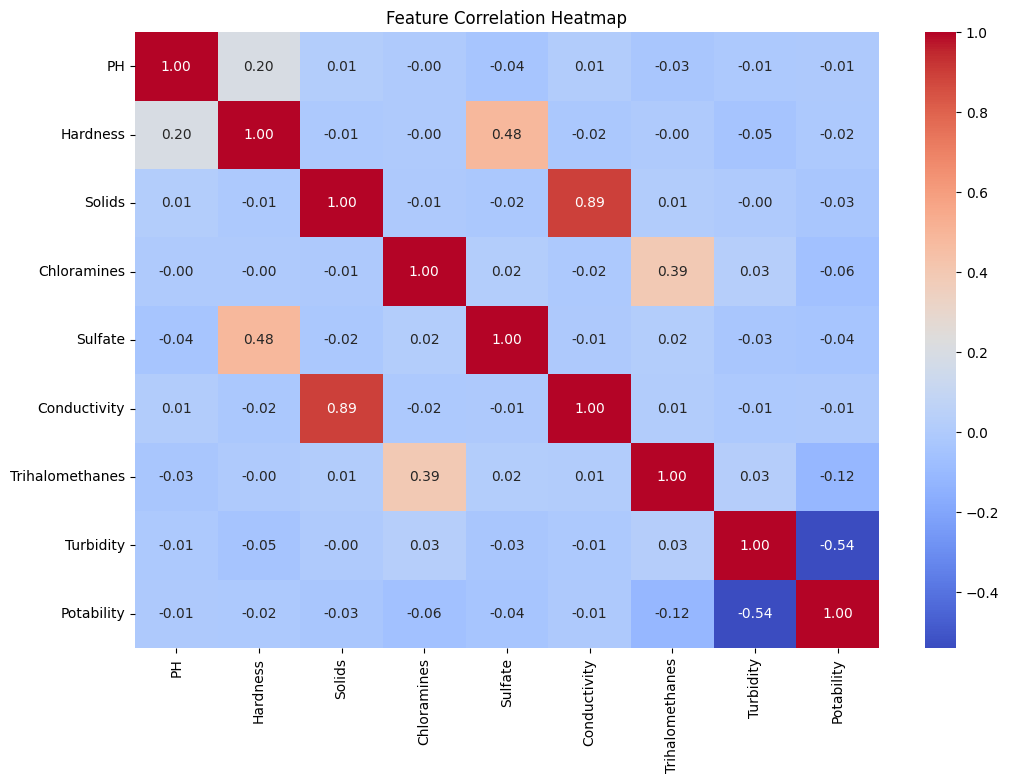

In [7]:
import seaborn as sns

plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

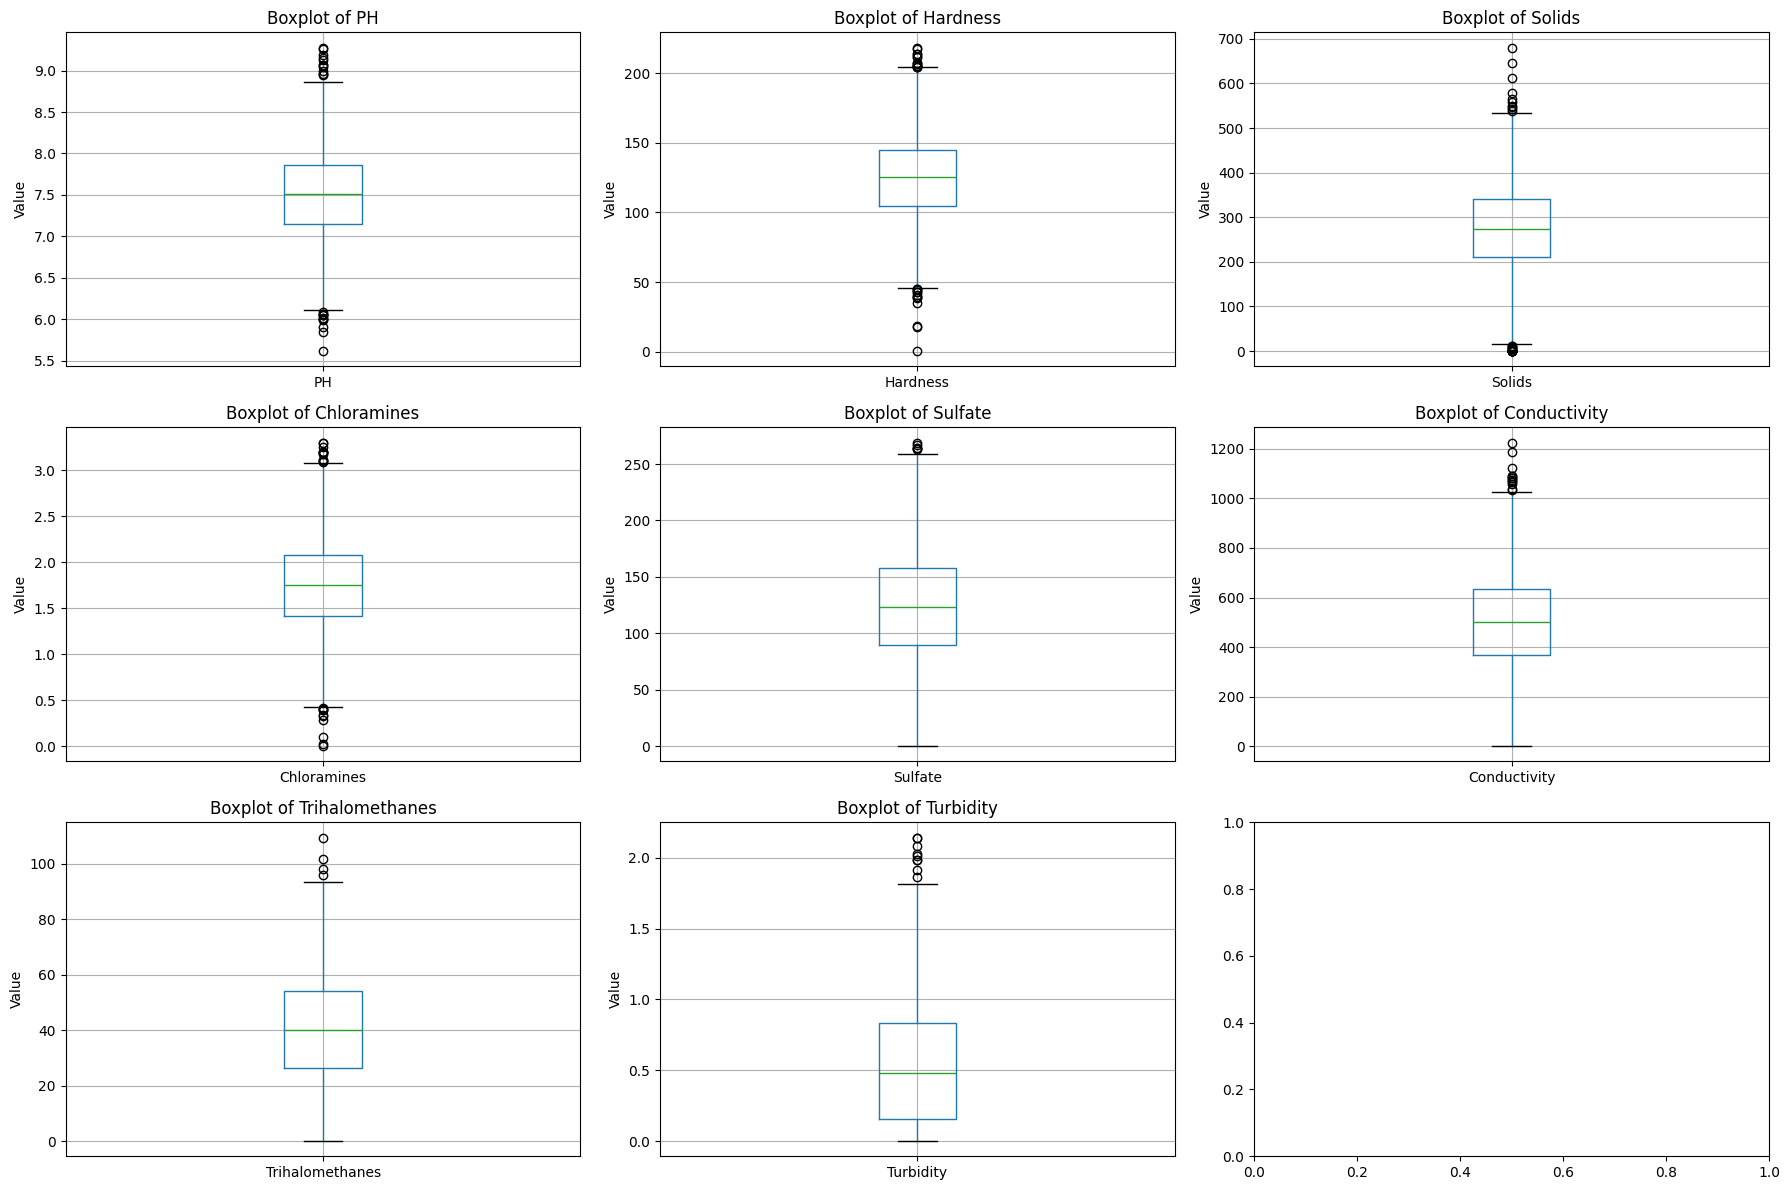

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns.drop('Potability')):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [9]:
# Remove outliers using the IQR method for each numeric column except 'Potability'
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Potability')
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep rows within 1.5*IQR for each feature
df_no_outliers = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
df_no_outliers.reset_index(drop=True, inplace=True)
df=df_no_outliers
df

,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
0,7.294480,109.747445,149.580579,2.514424,158.686922,180.522185,68.732337,0.673900,1
1,7.540417,130.701183,518.105852,2.134332,115.443943,752.190030,20.565890,0.657274,0
2,8.680964,126.168636,179.931717,1.828736,185.755707,417.489011,36.511400,0.315273,0
3,7.411797,160.169927,199.480251,1.596681,123.639254,442.419927,35.849044,0.000000,1
4,6.978071,123.167662,299.739836,2.217796,NaN,598.551053,54.565679,0.709806,1
...,...,...,...,...,...,...,...,...,...
2871,7.919654,175.952537,422.382676,2.127819,129.151373,680.917040,8.185826,0.410432,1
2872,8.287041,116.122304,441.454512,1.166615,85.469026,805.707004,24.318356,0.272758,1
2873,8.220683,129.810193,221.504342,1.253733,NaN,356.233975,44.877098,0.310676,1
2874,7.211526,128.430405,118.069081,2.022229,120.487352,124.134783,18.508324,1.070627,0


In [10]:
df.isnull().sum()

PH                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate            290
Conductivity         0
Trihalomethanes      0
Turbidity            0
Potability           0
dtype: int64

In [11]:
df = df.round(2)


In [12]:

df.isnull().sum()

PH                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate            290
Conductivity         0
Trihalomethanes      0
Turbidity            0
Potability           0
dtype: int64

In [39]:

df['Sulfate']=df['Sulfate'].fillna(df['Sulfate'].median())
df['Sulfate']=df['Sulfate'].round(2)


In [40]:
df.sample(10)

,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
2565,7.38,101.04,396.49,2.29,122.54,653.87,53.42,0.57,1
1453,7.60,171.52,52.46,1.61,210.41,0.00,37.65,0.40,1
146,7.36,108.24,290.30,2.21,162.79,454.30,43.20,0.09,1
1669,7.45,126.29,497.84,2.21,140.47,882.73,33.05,0.66,1
2834,7.29,120.02,379.03,2.66,163.54,797.98,40.55,0.71,1
2041,6.62,138.87,125.51,1.68,128.34,375.27,79.61,0.00,1
2288,8.12,94.32,320.38,1.51,61.79,567.08,37.16,0.29,1
1061,8.72,115.58,319.46,1.83,100.60,475.71,35.55,0.21,0
1370,7.85,126.70,211.86,1.56,129.36,326.42,17.42,0.00,1
1605,8.01,140.63,211.87,0.43,164.71,505.25,18.68,0.68,1


In [41]:
df.isnull().sum()

PH                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

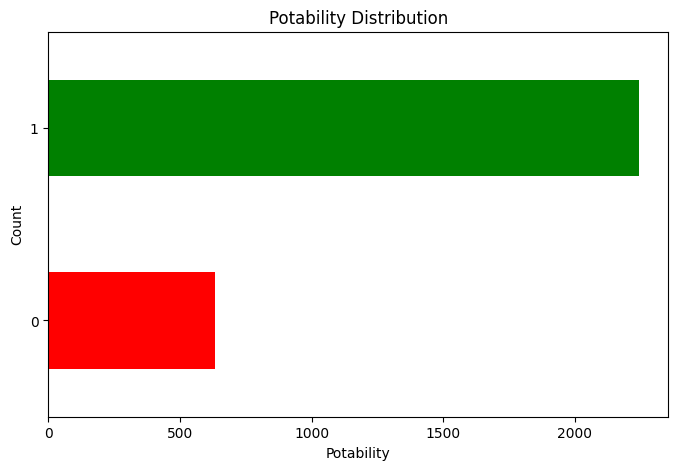

In [42]:
df['Potability'].value_counts().sort_index().plot(kind='barh', figsize=(8, 5), color=['red', 'green'])
plt.title('Potability Distribution')
plt.xlabel('Potability')
plt.ylabel('Count')

plt.show()

In [43]:
df['Potability'].value_counts()

Potability
1    2242
0     634
Name: count, dtype: int64

## Split the data for training and testing

In [19]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Potability',axis=1),df['Potability'],test_size=0.2,random_state=42)

In [44]:

df['Potability'].value_counts()

Potability
1    2242
0     634
Name: count, dtype: int64

In [ ]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# scaler.fit(x_train, x_test)
# X_train_scaled  = scaler.transform(x_train)
# X_test_scaled  = scaler.transform(x_test)

In [45]:
X=df.drop('Potability',axis=1)

In [46]:
x_test


,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity
612,7.75,101.95,247.48,1.91,152.490,443.79,30.62,0.59
1880,7.43,137.95,330.83,2.35,108.760,545.75,20.48,0.36
1357,7.72,159.32,367.44,2.26,209.850,679.11,48.41,0.74
2611,8.83,106.33,171.58,1.95,32.410,202.99,63.12,0.62
1047,7.06,138.73,162.27,1.07,165.930,295.70,30.07,0.57
...,...,...,...,...,...,...,...,...
1956,7.71,140.05,290.24,1.16,178.650,390.66,12.20,0.33
163,7.57,128.20,339.01,1.97,122.535,728.68,24.66,0.00
1918,6.69,172.93,255.54,1.71,178.650,342.47,63.46,1.09
252,8.27,121.76,150.44,1.74,60.410,543.52,80.35,0.26


# Model Comparison: Random Forest vs XGBoost vs Logistic Regression
We will train and evaluate both Random Forest and XGBoost classifiers to determine the best model for water quality estimation.

## Logistic Regression

In [47]:
lor=LogisticRegression(max_iter=5000)

In [48]:
lor.fit(x_train,y_train)

LogisticRegression(max_iter=5000)

In [50]:
y_pred=lor.predict(x_test)


In [67]:
# Evaluate Logistic Regression
lor_acc = accuracy_score(y_test, y_pred)
lor_f1 = f1_score(y_test, y_pred)
lor_roc = roc_auc_score(y_test, y_pred)
print('Logistic Regression Results:')
print(f'Accuracy: {lor_acc:.4f}')
print(f'F1 Score: {lor_f1:.4f}')
print(f'ROC-AUC: {lor_roc:.4f}')
print(classification_report(y_test, y_pred))

Logistic Regression Results:
Accuracy: 0.9201
F1 Score: 0.9507
ROC-AUC: 0.8346
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       126
           1       0.92      0.99      0.95       450

    accuracy                           0.92       576
   macro avg       0.93      0.83      0.87       576
weighted avg       0.92      0.92      0.92       576



In [68]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,

## Random Forest

In [69]:

from sklearn.ensemble import RandomForestClassifier


# Train Random Forest
rf1 = RandomForestClassifier(n_estimators=200, random_state=42)
rf1.fit(x_train, y_train)
rf_pred = rf1.predict(x_test)

# Evaluate Random Forest
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_pred)
print('Random Forest Results:')
print(f'Accuracy: {rf_acc:.4f}')
print(f'F1 Score: {rf_f1:.4f}')
print(f'ROC-AUC: {rf_roc:.4f}')
print(classification_report(y_test, rf_pred))




Random Forest Results:
Accuracy: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       126
           1       1.00      1.00      1.00       450

    accuracy                           1.00       576
   macro avg       1.00      1.00      1.00       576
weighted avg       1.00      1.00      1.00       576



## XGBoost

In [70]:

from xgboost import XGBClassifier

# Train XGBoost
xgb = XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

# Evaluate XGBoost
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc = roc_auc_score(y_test, xgb_pred)
print('XGBoost Results:')
print(f'Accuracy: {xgb_acc:.4f}')
print(f'F1 Score: {xgb_f1:.4f}')
print(f'ROC-AUC: {xgb_roc:.4f}')
print(classification_report(y_test, xgb_pred))

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:02:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
Accuracy: 0.9931
F1 Score: 0.9956
ROC-AUC: 0.9870
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       126
           1       0.99      1.00      1.00       450

    accuracy                           0.99       576
   macro avg       0.99      0.99      0.99       576
weighted avg       0.99      0.99      0.99       576



In [71]:
xgb_pred

array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,

In [73]:
# Compare and select the best model
print('--- Model Comparison ---')
print(f'Random Forest:       Accuracy={rf_acc:.4f}, F1={rf_f1:.4f}, ROC-AUC={rf_roc:.4f}')
print(f'XGBoost:             Accuracy={xgb_acc:.4f}, F1={xgb_f1:.4f}, ROC-AUC={xgb_roc:.4f}')
print(f'Logistic Regression: Accuracy={lor_acc:.4f}, F1={lor_f1:.4f}, ROC-AUC={lor_roc:.4f}')

if xgb_roc > rf_roc and xgb_roc > lor_roc:
    best_model = 'XGBoost'
elif rf_roc > xgb_roc and rf_roc > lor_roc:
    best_model = 'Random Forest'
else:
    best_model = 'Logistic Regression'
print(f'Best model for water quality estimation: {best_model}')

--- Model Comparison ---
Random Forest:       Accuracy=1.0000, F1=1.0000, ROC-AUC=1.0000
XGBoost:             Accuracy=0.9931, F1=0.9956, ROC-AUC=0.9870
Logistic Regression: Accuracy=0.9201, F1=0.9507, ROC-AUC=0.8346
Best model for water quality estimation: Random Forest


In [74]:
import pickle
# Save the trained Random Forest model as a pickle file
with open('water_quality_rf_model.pkl', 'wb') as f:
    pickle.dump(rf1, f)
print('Random forest model saved as water_quality_rf_model.pkl')

Random forest model saved as water_quality_rf_model.pkl


In [75]:
df


,PH,Hardness,Solids,Chloramines,Sulfate,Conductivity,Trihalomethanes,Turbidity,Potability
0,7.29,109.75,149.58,2.51,158.69,180.52,68.73,0.67,1
1,7.54,130.70,518.11,2.13,115.44,752.19,20.57,0.66,0
2,8.68,126.17,179.93,1.83,185.76,417.49,36.51,0.32,0
3,7.41,160.17,199.48,1.60,123.64,442.42,35.85,0.00,1
4,6.98,123.17,299.74,2.22,122.54,598.55,54.57,0.71,1
...,...,...,...,...,...,...,...,...,...
2871,7.92,175.95,422.38,2.13,129.15,680.92,8.19,0.41,1
2872,8.29,116.12,441.45,1.17,85.47,805.71,24.32,0.27,1
2873,8.22,129.81,221.50,1.25,122.54,356.23,44.88,0.31,1
2874,7.21,128.43,118.07,2.02,120.49,124.13,18.51,1.07,0
